In [5]:
import torch
from resnet import load_resnet_18

# Load the model architecture
model = load_resnet_18()

# Load the trained weights
model.load_state_dict(torch.load('./my_scripts/trained_resnet_with_fold_2/resnet_20.pth'))
model.eval()  # Set the model to evaluation mode

subject = 'SN018'
image_name = '03334.jpg'

d:\Oulu MSc\Autumn 2024\Affective Computing\FAUR\resnet.py:157: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load('pretrained/Resnet18_FER+_pytorch.pth.t

In [6]:
from PIL import Image
from torchvision import transforms
import pandas as pd
import numpy as np

# Use the same transformation as in your test set
transform = transforms.Compose([
    transforms.ToTensor(),
])

# Load and transform an image
image = Image.open(f'./all/{subject}/{image_name}')

# Load the labels from the CSV file
image_labels = pd.read_csv(f'./processed_labels_ice/{subject}.csv')

# Extract the image name without the extension
image_index = int(image_name.replace('.jpg', ''))

# Retrieve the corresponding row in the dataframe
frame = image_labels[image_labels['Frames'] == image_index + 1]

# Extract the Action Unit labels
AU_list = [1, 2, 4, 5, 6, 9, 12, 15, 17, 20, 25, 26]
labels = []
for i in AU_list:
    au_label = 'au' + str(i)
    value = frame[au_label].values[0] if not frame.empty else 0  # Default to 0 if frame is empty
    labels.append(value)

# Convert labels to a numpy array if needed
labels_array = np.array(labels)

input_tensor = transform(image).unsqueeze(0)  # Add batch dimension

In [7]:
with torch.no_grad():
    output = model(input_tensor)

# The output will be the predicted AU intensities
predicted_aus = output.squeeze().numpy() * 5

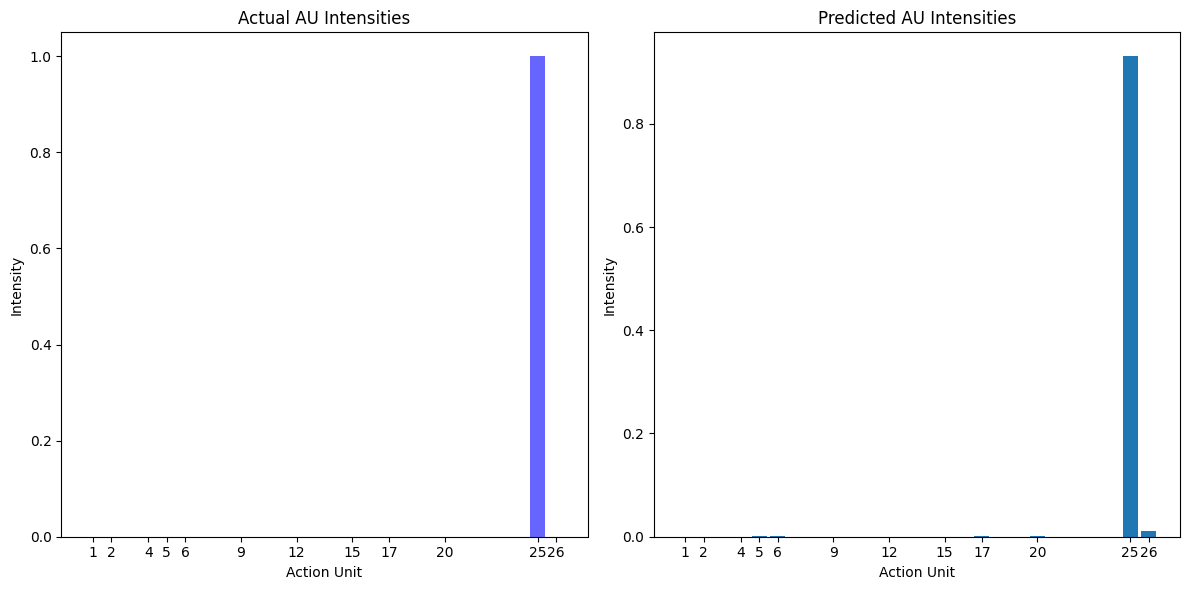

In [8]:
import matplotlib.pyplot as plt
# Plotting predicted vs actual labels
plt.figure(figsize=(12, 6))

# Bar plot for actual labels
plt.subplot(1, 2, 1)
plt.bar(AU_list, labels_array, color='blue', alpha=0.6, label='Actual Labels')
plt.title('Actual AU Intensities')
plt.xlabel('Action Unit')
plt.ylabel('Intensity')
plt.xticks(AU_list)

# Display the predicted AU intensities
plt.subplot(1, 2, 2)
plt.bar(AU_list, predicted_aus)
plt.title('Predicted AU Intensities')
plt.xlabel('Action Unit')
plt.ylabel('Intensity')
plt.xticks(AU_list)

plt.tight_layout()
plt.show()